<a href="https://colab.research.google.com/github/isawich/Visi-Komputer-TI-2C/blob/main/Object_Detection_Viskom.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 44.3 MB/s eta 0:00:00


In [4]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="U2ErRCXip8LIJZ0OBIi0")
project = rf.workspace("revathibirapaka").project("stationary-dataset-gfglf")
version = project.version(1)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Stationary-Dataset-1 in yolov8:: 100%|██████████| 5604/5604 [00:00<00:00, 6403.46it/s]


In [5]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")  # model paling ringan & cepat

model.train(
    data="Stationary-Dataset-1/data.yaml",
    epochs=30,
    imgsz=640
)

Ultralytics 8.3.239 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Stationary-Dataset-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pos

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x798d57b8c0b0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.

In [6]:
model = YOLO("runs/detect/train2/weights/best.pt")

results = model.predict(
    source="Stationary-Dataset-1/test/images",
    conf=0.5,
    save=True
)


image 1/95 /content/Stationary-Dataset-1/test/images/21i2279_Ballpoint-13-_jpg.rf.15b7e1ac13ad0892199fe4026d243a70.jpg: 640x640 (no detections), 8.7ms
image 2/95 /content/Stationary-Dataset-1/test/images/21i2279_Ballpoint-21-_jpg.rf.c708abab2a13ed3ef9eccf86f1aa7640.jpg: 640x640 (no detections), 7.2ms
image 3/95 /content/Stationary-Dataset-1/test/images/21i2279_Book-19-_jpg.rf.3bfe9736d58cd50074e2205081bf8625.jpg: 640x640 (no detections), 7.3ms
image 4/95 /content/Stationary-Dataset-1/test/images/21i2279_Book-40-_jpg.rf.318f642bb9d42579722aa87ec751cfb8.jpg: 640x640 9 books, 7.3ms
image 5/95 /content/Stationary-Dataset-1/test/images/21i2279_Book-48-_jpg.rf.557cc59243e695d14ade28680a7a5d14.jpg: 640x640 1 book, 7.3ms
image 6/95 /content/Stationary-Dataset-1/test/images/21i2279_Eraser-17-_jpg.rf.3f3c2403098304080b24896b05f3d0ea.jpg: 640x640 1 eraser, 8.7ms
image 7/95 /content/Stationary-Dataset-1/test/images/21i2279_Eraser-20-_jpg.rf.9ce340a7516ec9350417c28a39b640d6.jpg: 640x640 1 eraser, 

Uji Gambar 1

In [7]:
model.predict(
    source="coba.jpg",
    conf=0.18,
    save=True
)



image 1/1 /content/coba.jpg: 640x640 1 eraser, 2 pencils, 2 sharpeners, 7.2ms
Speed: 2.7ms preprocess, 7.2ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'Marker', 1: 'Notebook', 2: 'ball point', 3: 'book', 4: 'eraser', 5: 'marker', 6: 'notebook', 7: 'pencil', 8: 'pointer', 9: 'scale', 10: 'sharpener', 11: 'sharpener-'}
 obb: None
 orig_img: array([[[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        ...,
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
       

(np.float64(-0.5), np.float64(719.5), np.float64(719.5), np.float64(-0.5))

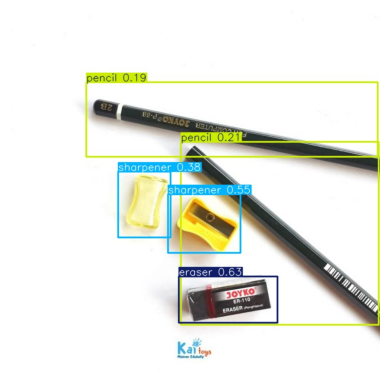

In [9]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("runs/detect/predict/coba.jpg")
plt.imshow(img)
plt.axis('off')

Uji Gambar 2


In [10]:
model.predict(
    source="bisaa.jpg",
    conf=0.25,
    save=True
)



image 1/1 /content/bisaa.jpg: 640x608 1 eraser, 1 pencil, 71.7ms
Speed: 4.2ms preprocess, 71.7ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 608)
Results saved to /content/runs/detect/predict


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'Marker', 1: 'Notebook', 2: 'ball point', 3: 'book', 4: 'eraser', 5: 'marker', 6: 'notebook', 7: 'pencil', 8: 'pointer', 9: 'scale', 10: 'sharpener', 11: 'sharpener-'}
 obb: None
 orig_img: array([[[242, 242, 242],
         [242, 242, 242],
         [242, 242, 242],
         ...,
         [242, 242, 242],
         [242, 242, 242],
         [242, 242, 242]],
 
        [[242, 242, 242],
         [242, 242, 242],
         [242, 242, 242],
         ...,
         [242, 242, 242],
         [242, 242, 242],
         [242, 242, 242]],
 
        [[242, 242, 242],
         [242, 242, 242],
         [242, 242, 242],
         ...,
         [242, 242, 242],
         [242, 242, 242],
         [242, 242, 242]],
 
        ...,
 
        [[242, 242, 242],
         [242, 242, 242],
         [242, 242, 242],
         ...,
         [242, 242, 242],
       

(np.float64(-0.5), np.float64(719.5), np.float64(786.5), np.float64(-0.5))

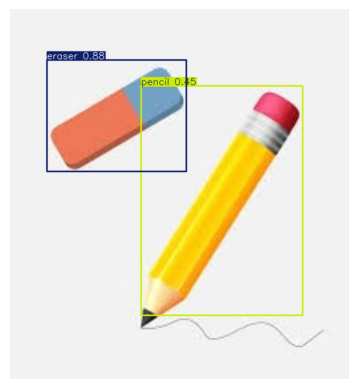

In [11]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("runs/detect/predict/bisaa.jpg")
plt.imshow(img)
plt.axis('off')

Uji Gambar 3

In [12]:
model.predict(
    source="yoi.jpg",
    conf=0.25,
    save=True
)



image 1/1 /content/yoi.jpg: 640x640 1 pencil, 2 sharpeners, 9.8ms
Speed: 2.9ms preprocess, 9.8ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'Marker', 1: 'Notebook', 2: 'ball point', 3: 'book', 4: 'eraser', 5: 'marker', 6: 'notebook', 7: 'pencil', 8: 'pointer', 9: 'scale', 10: 'sharpener', 11: 'sharpener-'}
 obb: None
 orig_img: array([[[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        ...,
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
       

(np.float64(-0.5), np.float64(224.5), np.float64(224.5), np.float64(-0.5))

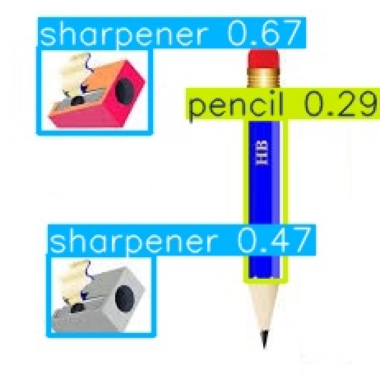

In [13]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("runs/detect/predict/yoi.jpg")
plt.imshow(img)
plt.axis('off')

Uji Gambar 4

In [14]:
model.predict(
    source="hapus.jpeg",
    conf=0.25,
    save=True
)


image 1/1 /content/hapus.jpeg: 640x640 2 erasers, 24.8ms
Speed: 11.3ms preprocess, 24.8ms inference, 4.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'Marker', 1: 'Notebook', 2: 'ball point', 3: 'book', 4: 'eraser', 5: 'marker', 6: 'notebook', 7: 'pencil', 8: 'pointer', 9: 'scale', 10: 'sharpener', 11: 'sharpener-'}
 obb: None
 orig_img: array([[[230, 230, 230],
         [230, 230, 230],
         [230, 230, 230],
         ...,
         [233, 231, 230],
         [233, 231, 230],
         [233, 231, 230]],
 
        [[230, 230, 230],
         [230, 230, 230],
         [230, 230, 230],
         ...,
         [234, 232, 231],
         [234, 232, 231],
         [234, 232, 231]],
 
        [[230, 230, 230],
         [230, 230, 230],
         [230, 230, 230],
         ...,
         [234, 232, 231],
         [234, 232, 231],
         [234, 232, 231]],
 
        ...,
 
        [[234, 234, 234],
         [234, 234, 234],
         [234, 234, 234],
         ...,
         [239, 239, 239],
       

(np.float64(-0.5), np.float64(224.5), np.float64(224.5), np.float64(-0.5))

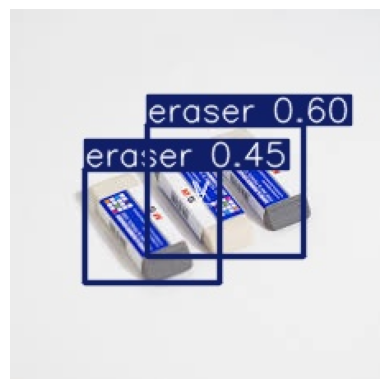

In [15]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("runs/detect/predict/hapus.jpg")
plt.imshow(img)
plt.axis('off')

Uji Gambar 5

In [26]:
model.predict(
    source="p.jpeg",
    conf=0.3,
    save=True
)



image 1/1 /content/p.jpeg: 640x640 1 ball point, 11.1ms
Speed: 4.2ms preprocess, 11.1ms inference, 2.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'Marker', 1: 'Notebook', 2: 'ball point', 3: 'book', 4: 'eraser', 5: 'marker', 6: 'notebook', 7: 'pencil', 8: 'pointer', 9: 'scale', 10: 'sharpener', 11: 'sharpener-'}
 obb: None
 orig_img: array([[[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        ...,
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
       

(np.float64(-0.5), np.float64(699.5), np.float64(699.5), np.float64(-0.5))

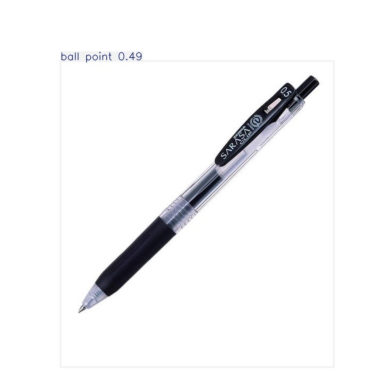

In [27]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("runs/detect/predict/p.jpg")
plt.imshow(img)
plt.axis('off')